# <b> Reiforcement Learning Agent : Optimal Execution  </b>

## <b> Adrián Vazquez </b>

In [1]:
# libs
import plotly.io as pio
#pio.renderers.default = "notebook_connected+png" 

from IPython.display import Image, display
import sys
import os
# Add project root to path
sys.path.append(os.path.abspath(".."))

# libs 
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from src.models.twap import twap_schedule
from src.models.vwap import generate_vwap_schedule
from src.models.inventory_from_schedule import inventory_from_schedule
from src.models.almgren_chriss_shedule import almgren_chriss_schedule
from src.analytics.implementation_shortfall import implementation_shortfall
from src.analytics.get_intraday_prices import get_intraday_prices
from src.models.simulate_brownian_motion_price_path import simulate_brownian_price_path, simulate_multiple_price_paths, simulate_execution_prices
from src.models.volume_aware_ac_schedule import volume_aware_ac_schedule

(1716, 5)
2026-04-22 09:30:00
2026-05-21 15:55:00


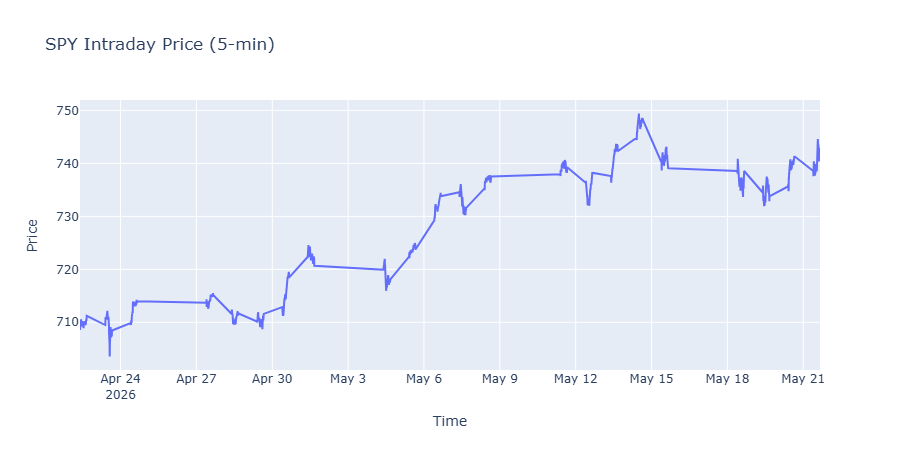

In [ ]:
# price dataset
API_KEY = "API_KEY"

df_spy_5min = get_intraday_prices(
    symbol="SPY",
    api_key=API_KEY,
    interval="5min",
    outputsize="full",
    extended_hours="false"
)

# ensure datetime index
df_spy_5min.index = pd.to_datetime(df_spy_5min.index)

# sorting
df_spy_5min = df_spy_5min.sort_index()

# remove duplicated timestamps
df_spy_5min = df_spy_5min[~df_spy_5min.index.duplicated()]

# keep regular market hours only
df_spy_5min = df_spy_5min.between_time("09:30", "15:55")

# quick checks
print(df_spy_5min.shape)
print(df_spy_5min.index.min())
print(df_spy_5min.index.max())

# plot
fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=df_spy_5min.index,
        y=df_spy_5min["Close"],
        mode="lines",
        name="SPY Close"
    )
)

fig.update_layout(
    title="SPY Intraday Price (5-min)",
    xaxis_title="Time",
    yaxis_title="Price",
    height=450,
    width=900
)

fig.show()
fig.write_image("../results/plots/SPY_Intraday_Price_5min.png")
display(Image(filename="../results/plots/SPY_Intraday_Price_5min.png"))

# Market State Representation for Reinforcement Learning Execution

## Objective

The objective of this section is to construct a market state representation capable of describing the intraday trading environment for an execution agent based on Reinforcement Learning (RL).

Unlike price prediction models, optimal execution focuses on minimizing:

- execution costs,
- market impact,
- inventory risk,
- adverse price movements during execution.

Therefore, the selected features are not intended to forecast long-term returns, but rather to characterize:

- liquidity conditions,
- short-term market dynamics,
- execution frictions,
- urgency of execution.

---

# Theoretical Motivation

The feature selection is inspired by the optimal execution and market microstructure literature, particularly:

---

## Almgren & Chriss (2000)

> “Optimal Execution of Portfolio Transactions”

Almgren and Chriss formulate optimal execution as a trade-off between:

$
\text{Execution Cost}
+
\text{Inventory Risk} $

Their framework motivates the inclusion of:

- volatility,
- remaining inventory,
- time remaining.

---

## Bertsimas & Lo (1998)

> “Optimal Control of Execution Costs”

This work introduces the idea that execution quality depends dynamically on market conditions over time, motivating the use of:

- temporal market states,
- adaptive execution decisions,
- liquidity-sensitive trading.

---

## Nevmyvaka, Feng & Kearns (2006)

> “Reinforcement Learning for Optimized Trade Execution”

One of the earliest applications of Reinforcement Learning to optimal execution.

The authors use state variables related to:

- remaining inventory,
- time remaining,
- market volume,
- spread,
- price movements.

This paper strongly motivates the RL state design used in this project.

---

## Cartea, Jaimungal & Penalva

> “Algorithmic and High-Frequency Trading”

This work emphasizes that execution quality is highly dependent on liquidity and market microstructure dynamics rather than directional forecasting alone.

The book motivates features associated with:

- intraday liquidity,
- volatility,
- spread dynamics,
- market impact.

---

# Selected Features

The market state is divided into four conceptual layers:

---

# 1. Price Dynamics Features

These variables describe short-term market behavior and price movement characteristics.

## Returns

$ r_t = \frac{P_t - P_{t-1}}{P_{t-1}} $

Purpose:
- Capture immediate price movement.
- Allow the agent to detect short-term directional pressure.

---

## Rolling Volatility

$ \sigma_t = \text{Std}(r_{t-k:t}) $

Purpose:
- Approximate execution risk.
- High volatility increases uncertainty and inventory risk.

Motivation:
- Directly connected to the risk term in Almgren-Chriss.

---

## Momentum

$ \text{Momentum}_t = P_t - \text{MA}_k(P_t) $

Purpose:
- Detect short-term directional persistence.
- Avoid adverse execution during aggressive price moves.

---

# 2. Liquidity Features

These variables attempt to characterize the market's ability to absorb trades.

## Relative Volume

$
\text{RelVolume}_t =
\frac{V_t}{\text{RollingMean}(V_t)} $

Purpose:
- Measure whether current liquidity is above or below normal conditions.
- High relative volume generally implies lower market impact.

Motivation:
- The empirical results obtained in previous sections showed that liquidity conditions strongly affect execution quality.

---

## Intraday Volume Profile

$ \text{VolumeProfile}(t) $

Purpose:
- Capture the well-known U-shaped intraday liquidity curve.
- Allow the agent to exploit periods of naturally high liquidity.

Observation:
- VWAP performance superiority suggests that volume-aware execution is essential.

---

# 3. Friction Features

These variables approximate trading frictions and execution difficulty.

## Spread Proxy

Since bid-ask spread data is unavailable through Alpha Vantage, the following proxy is used:

$ \text{SpreadProxy}_t = High_t - Low_t $

Purpose:
- Approximate market friction and short-term trading cost.
- Wider intraday ranges often imply lower execution efficiency.

---

# 4. Agent State Variables

These variables describe the internal state of the execution problem.

---

## Remaining Inventory

$ \frac{x_t}{Q} $

Where:
- \(x_t\) = remaining shares,
- \(Q\) = total parent order.

Purpose:
- Measure execution progress.
- Remaining inventory determines urgency and residual risk.

---

## Time Remaining

$
\frac{t}{T} $

Purpose:
- Represent remaining execution horizon.
- Necessary for dynamic scheduling decisions.

---

# Final State Representation

The final state vector used by the RL execution agent is:

$ 
s_t =
\left[
\frac{x_t}{Q},
\frac{t}{T},
\text{RelVolume}_t,
\text{RollingVol}_t,
\text{SpreadProxy}_t,
\text{Momentum}_t
\right] $

This representation combines:

- market liquidity,
- execution risk,
- market frictions,
- internal execution urgency.

---

# Important Design Philosophy

The objective of this RL framework is not to predict long-term market direction.

Instead, the agent attempts to learn:

> *When is the market capable of absorbing inventory at lower execution cost?*

This aligns with the central insight observed throughout the project:

> Liquidity conditions dominate execution quality.

The Reinforcement Learning agent is therefore designed as an adaptive execution policy capable of reacting dynamically to changing market conditions.

In [3]:
df_market_state = df_spy_5min.copy()

df_market_state.index = pd.to_datetime(df_market_state.index)
df_market_state = df_market_state.sort_index()

# =========================================================
# price dynamics
# =========================================================

df_market_state["returns"] = (
    df_market_state["Close"].pct_change()
)

df_market_state["rolling_vol"] = (
    df_market_state["returns"]
    .rolling(window=20)
    .std()
)

df_market_state["momentum"] = (
    df_market_state["Close"]
    - df_market_state["Close"].rolling(window=5).mean()
)

# =========================================================
# liquidity dynamics
# =========================================================

df_market_state["rel_volume"] = (
    df_market_state["Volume"]
    / df_market_state["Volume"].rolling(window=20).mean()
)

df_market_state["minute_of_day"] = (
    df_market_state.index.hour * 60
    + df_market_state.index.minute
)

volume_profile = (
    df_market_state
    .groupby("minute_of_day")["Volume"]
    .mean()
)

df_market_state["volume_profile"] = (
    df_market_state["minute_of_day"]
    .map(volume_profile)
)

df_market_state["volume_profile_norm"] = (
    df_market_state["volume_profile"]
    / df_market_state["volume_profile"].mean()
)

# =========================================================
# friction dynamics
# =========================================================

df_market_state["spread_proxy"] = (
    df_market_state["High"]
    - df_market_state["Low"]
)

df_market_state["spread_proxy_pct"] = (
    df_market_state["spread_proxy"]
    / df_market_state["Close"]
)

# =========================================================
# feature columns
# =========================================================

feature_cols = [
    "returns",
    "rolling_vol",
    "momentum",
    "rel_volume",
    "volume_profile_norm",
    "spread_proxy_pct"
]

# =========================================================
# remove NaN values
# =========================================================

df_market_state = df_market_state.dropna(
    subset=feature_cols
)

# =========================================================
# build single-day execution dataset
# =========================================================

df_market_state["date"] = df_market_state.index.date

last_day = df_market_state["date"].max()

df_day = (
    df_market_state[
        df_market_state["date"] == last_day
    ]
    .drop(columns=["date"])
    .copy()
)

# =========================================================
# quick checks
# =========================================================

print("Selected day:", last_day)
print("df_day shape:", df_day.shape)

df_day[feature_cols].head()

Selected day: 2026-05-21
df_day shape: (78, 14)


,returns,rolling_vol,momentum,rel_volume,volume_profile_norm,spread_proxy_pct
2026-05-21 09:30:00,-0.003696,0.000947,-2.073,1.784789,2.542568,0.001449
2026-05-21 09:35:00,-0.001192,0.000969,-2.241,1.070472,1.296203,0.001410
2026-05-21 09:40:00,-0.000041,0.000960,-1.584,0.795604,1.192268,0.001112
2026-05-21 09:45:00,-0.000095,0.000949,-0.974,1.068879,1.363361,0.001282
2026-05-21 09:50:00,0.002779,0.001127,1.410,1.470964,1.319893,0.003015


In [4]:
for col in feature_cols:
    fig = go.Figure()

    fig.add_trace(
        go.Scatter(
            x=df_market_state.index,
            y=df_market_state[col],
            mode="lines",
            name=col
        )
    )

    fig.update_layout(
        title=f"{col} - Market State Feature",
        xaxis_title="Time",
        yaxis_title=col,
        height=350,
        width=900
    )

    fig.show()

# State Builder

## Objective

In Reinforcement Learning (RL), the agent cannot directly interpret financial concepts such as:

- liquidity,
- volatility,
- inventory risk,
- execution urgency.

Instead, the environment must transform the market information into a numerical representation called the **state vector**.

The component responsible for constructing this representation is called the **State Builder**.

---

# Definition

At each timestep $ t $, the State Builder creates a vector:

$
s_t
$

that summarizes:

- the current market condition,
- the execution environment,
- the remaining execution problem.

This vector becomes the input of the Reinforcement Learning agent.

---

# Financial Interpretation

The state vector attempts to answer the following question:

> *What information should an execution agent observe before deciding how aggressively to trade?*

The agent uses this information to determine the optimal execution action.

---

# State Representation

The market state used in this project is defined as:

$
s_t =
\left[
\frac{x_t}{Q},
\frac{t}{T},
\text{RelVolume}_t,
\text{RollingVol}_t,
\text{SpreadProxy}_t,
\text{Momentum}_t
\right]
$

---


# Why the State Builder Matters

The quality of the Reinforcement Learning agent depends heavily on the quality of the state representation.

In optimal execution problems:

> The challenge is not only learning a policy, but correctly representing the market state.

A poorly designed state may prevent the agent from learning meaningful execution behavior, regardless of the complexity of the neural network.

---

# Conceptual Flow

The State Builder transforms:

$
\text{Market Information}
+
\text{Execution Information}
$

into:

$
s_t
$

which is then passed to the DQN agent:

$
s_t \rightarrow \text{DQN} \rightarrow a_t
$

Where:

- $s_t $ = market state,
- $a_t$ = execution action.

---

# Final Interpretation

The State Builder allows the Reinforcement Learning agent to observe:

- liquidity conditions,
- execution frictions,
- market dynamics,
- inventory urgency,

before deciding:

> *How much inventory should be executed at the current timestep?*

In [5]:
class StateBuilder:
    def __init__(self, market_data, feature_cols):
        self.market_data = market_data.reset_index(drop=True).copy()
        self.feature_cols = feature_cols

    def build_state(self, t, inventory_remaining, order_size):
        """
        Build the RL state vector at timestep t.

        State:
        [
            inventory_remaining / order_size,
            time_remaining / total_steps,
            rel_volume_t,
            rolling_vol_t,
            spread_proxy_pct_t,
            momentum_t
        ]
        """

        total_steps = len(self.market_data)

        inventory_ratio = inventory_remaining / order_size
        time_remaining = (total_steps - t - 1) / total_steps

        market_features = (
            self.market_data
            .loc[t, self.feature_cols]
            .values
            .astype(np.float32)
        )

        state = np.concatenate([
            np.array(
                [inventory_ratio, time_remaining],
                dtype=np.float32
            ),
            market_features
        ])

        return state

In [6]:
state_features = [
    "rel_volume",
    "rolling_vol",
    "spread_proxy_pct",
    "momentum"
]

state_builder = StateBuilder(
    market_data=df_day,
    feature_cols=state_features
)

Q = 100_000
inventory_remaining = 60_000
t = 10

state_t = state_builder.build_state(
    t=t,
    inventory_remaining=inventory_remaining,
    order_size=Q
)

state_t

array([ 6.0000002e-01,  8.5897434e-01,  9.4699037e-01,  1.2128296e-03,
        1.3349054e-03, -1.3209800e+00], dtype=float32)

# Execution Environment

The Execution Environment is the core simulation engine of the Reinforcement Learning framework.
Its objective is to simulate the execution of a large parent order over a fixed intraday horizon.
At each timestep, the agent observes the current market state, selects an execution action, and receives a reward based on the quality of that execution decision.

---

# Reinforcement Learning Structure

The execution problem is represented as a sequential decision-making problem.

At each timestep \(t\):

$
s_t \rightarrow a_t \rightarrow r_t \rightarrow s_{t+1}
$

Where:

- $ s_t $ = current market state,
- $a_t $ = execution action,
- $ r_t $  = reward or penalty,
- $ s_{t+1} $ = next market state.

---

# Financial Interpretation

The agent is solving the following question:

> *Given the current market conditions, remaining inventory, and remaining time, how much should I execute now?*

This transforms optimal execution into a dynamic control problem.

---

# Episode Definition

An episode represents the execution of one parent order:

$
Q
$

over a fixed number of intraday intervals:

$
T
$

For example:

- $ Q = 100{,}000 $ shares,
- $ T = 78 $ five-minute intervals,
- execution horizon = one full trading day.

At the beginning of the episode:

$
x_0 = Q
$

At the end of the episode, the objective is:

$
x_T = 0
$

Where $ x_t $ represents remaining inventory.

---

# Action Space

The DQN agent requires a discrete action space.

Each action represents the fraction of remaining inventory to execute at timestep \(t\):

$
a_t \in (0.00,\ 0.10,\ 0.25,\ 0.50,\ 0.75,\ 1.00)
$

If the agent selects:

$
a_t = 0.25
$

then the number of shares executed is:

$
q_t = 0.25 \cdot x_t
$

Where:

- $q_t$ = shares executed at timestep $t $,
- $ x_t $ = remaining inventory before execution.

To avoid over-execution:

$
q_t = \min(q_t, x_t)
$

At the final timestep, the remaining inventory must be liquidated:

$
q_T = x_T
$

---

# Market Impact Model

Since order book data is not available, the environment uses a simplified temporary market impact model based on participation rate.

The participation rate is defined as:

$
\rho_t = \frac{q_t}{V_t}
$

Where:

- $ q_t & = shares executed by the agent,
- $ V_t $ = market volume at timestep $ t $.

For a buy order, the execution price is modeled as:

$
P^{exec}_t =
P_t
+
\eta \rho_t
$

Where:

- $ P^{exec}_t $ = execution price,
-  $ P_t $ = market price,
- $ \eta $ = temporary impact parameter,
- $ \rho_t $ = participation rate.

This means that larger trades relative to available market volume generate higher execution costs.

---

# Execution Cost

For a buy order, the step execution cost can be approximated as:

$ 
C_t =
q_t
\left(
P^{exec}_t - P_0
\right)
$

Where:

- $P_0$ = arrival price,
- $P^{exec}_t $ = impacted execution price.

This cost is related to implementation shortfall.

---

# Reward Function

The reward is designed as a penalty function.

The agent is penalized for:

1. expensive execution,
2. excessive market impact,
3. holding too much inventory,
4. failing to complete the order.

A practical reward function is:

$ r_t = -
\left[
C_t
+
\lambda x_t^2
+
\kappa \rho_t^2
\right]
$

Where:

- $ C_t $ = execution cost,
- $ x_t^2 $ = inventory risk penalty,
- $ \rho_t^2 $ = participation/impact penalty,
- $ \lambda $= inventory risk aversion parameter,
- $ \kappa $ = impact penalty parameter.

At the terminal step, an additional penalty is applied if inventory remains:

$
r_T =
r_T -
\phi x_T^2
$ 

Where:

- $ \phi $ = terminal liquidation penalty.

---

# Environment Transition

After the agent selects an action:

$
a_t
$

the environment performs the following steps:

1. Converts the action into shares executed:

$
q_t = a_t x_t
$

2. Computes participation rate:

$
\rho_t = \frac{q_t}{V_t}
$

3. Computes impacted execution price:

$
P^{exec}_t = P_t + \eta \rho_t
$

4. Updates remaining inventory:

$
x_{t+1} = x_t - q_t
$

5. Computes reward:

$
r_t
$

6. Advances to the next timestep:

$
t \leftarrow t + 1
$

7. Builds the next state:

$
s_{t+1}
$

---

# Environment Methods

The environment is implemented with two core methods.

---

## `reset()`

Initializes a new execution episode.

It resets:

- current timestep,
- remaining inventory,
- cumulative cost,
- execution history.

It returns the initial state:

$
s_0
$

---

## `step(action)`

Executes one decision step.

It receives:

$
a_t
$

and returns:

$
s_{t+1}, r_t, done, info
$

Where:

- $s_{t+1} $ = next state,
- $ r_t $ = reward,
- `done` = whether the episode has ended,
- `info` = additional execution diagnostics.

---

# Why the Environment Matters

In Reinforcement Learning for optimal execution, the environment is more important than the neural network architecture.

The environment defines:

- how trades affect costs,
- how market impact is simulated,
- how inventory risk is penalized,
- how the agent learns good or bad execution behavior.

A poorly designed environment can lead to unrealistic policies, even if the DQN model is technically correct.

---

# Final Interpretation

The Execution Environment transforms the optimal execution problem into a controlled simulation where the agent learns:

> *Execute more aggressively when liquidity is favorable and execution risk is low, but avoid excessive participation and complete the order before the horizon ends.*

This aligns with the central conclusion of the previous sections:

> Liquidity is the dominant driver of execution quality.

In [7]:
class ExecutionEnv:
    def __init__(
        self,
        market_data,
        state_builder,
        order_size=100_000,
        action_space=None,
        eta=0.05,
        inventory_penalty=1e-10,
        participation_penalty=1e-2,
        terminal_penalty=1e-6
    ):
        self.market_data = market_data.reset_index(drop=True).copy()
        self.state_builder = state_builder
        self.order_size = order_size

        self.action_space = action_space or  np.linspace(0.00,0.05,51).tolist()

        self.eta = eta
        self.inventory_penalty = inventory_penalty
        self.participation_penalty = participation_penalty
        self.terminal_penalty = terminal_penalty

        self.total_steps = len(self.market_data)

        self.reset()

    def reset(self):
        self.t = 0
        self.inventory_remaining = self.order_size
        self.arrival_price = float(self.market_data.loc[0, "Close"])

        self.cumulative_cost = 0.0
        self.execution_history = []

        state = self.state_builder.build_state(
            t=self.t,
            inventory_remaining=self.inventory_remaining,
            order_size=self.order_size
        )

        return state

    def step(self, action_idx):
        action_fraction = self.action_space[action_idx]

        price = float(self.market_data.loc[self.t, "Close"])
        volume = float(self.market_data.loc[self.t, "Volume"])

        volume = max(volume, 1.0)

        # Force liquidation at final step
        is_last_step = self.t == self.total_steps - 1

        if is_last_step:
            shares_to_trade = self.inventory_remaining
        else:
            shares_to_trade = action_fraction * self.order_size

        shares_to_trade = min(shares_to_trade, self.inventory_remaining)

        participation_rate = shares_to_trade / volume

        # Temporary market impact model
        execution_price = price + self.eta * participation_rate

        # Implementation shortfall-style cost
        step_cost = shares_to_trade * (execution_price - self.arrival_price)

        self.cumulative_cost += step_cost

        # Update inventory
        self.inventory_remaining -= shares_to_trade

        # Reward as negative penalty
        reward = -step_cost
        reward -= self.inventory_penalty * (self.inventory_remaining ** 2)
        reward -= self.participation_penalty * (participation_rate ** 2)

        # Terminal penalty if inventory remains
        if is_last_step and self.inventory_remaining > 0:
            reward -= self.terminal_penalty * (self.inventory_remaining ** 2)

        self.execution_history.append({
            "t": self.t,
            "price": price,
            "volume": volume,
            "action_fraction": action_fraction,
            "shares_traded": shares_to_trade,
            "inventory_remaining": self.inventory_remaining,
            "participation_rate": participation_rate,
            "execution_price": execution_price,
            "step_cost": step_cost,
            "cumulative_cost": self.cumulative_cost,
            "reward": reward
        })

        self.t += 1

        done = (
            self.t >= self.total_steps
            or self.inventory_remaining <= 0
        )

        if done:
            next_state = np.zeros_like(
                self.state_builder.build_state(
                    t=0,
                    inventory_remaining=self.order_size,
                    order_size=self.order_size
                )
            )
        else:
            next_state = self.state_builder.build_state(
                t=self.t,
                inventory_remaining=self.inventory_remaining,
                order_size=self.order_size
            )

        info = {
            "t": self.t,
            "inventory_remaining": self.inventory_remaining,
            "cumulative_cost": self.cumulative_cost,
            "participation_rate": participation_rate,
            "shares_traded": shares_to_trade,
            "execution_price": execution_price
        }

        return next_state, reward, done, info

    def get_execution_history(self):
        return pd.DataFrame(self.execution_history)

In [8]:
env = ExecutionEnv(
    market_data=df_market_state,
    state_builder=state_builder,
    order_size=100_000,
    eta=0.05,
    inventory_penalty=1e-10,
    participation_penalty=1e-2,
    terminal_penalty=1e-6
)

state = env.reset()
done = False

while not done:
    action_idx = np.random.choice(len(env.action_space))
    next_state, reward, done, info = env.step(action_idx)
    state = next_state

history_random = env.get_execution_history()

history_random.head()

,t,price,volume,action_fraction,shares_traded,inventory_remaining,participation_rate,execution_price,step_cost,cumulative_cost,reward
0,0,709.84,220476.0,0.013,1300.0,98700.0,0.005896,709.840295,0.383262,0.383262,-1.357431
1,1,709.91,244720.0,0.011,1100.0,97600.0,0.004495,709.910225,77.247221,77.630483,-78.199798
2,2,710.19,500586.0,0.023,2300.0,95300.0,0.004595,710.190230,805.528381,883.158864,-806.436590
3,3,710.20,433990.0,0.036,3600.0,91700.0,0.008295,710.200415,1297.493122,2180.651986,-1298.334012
4,4,710.08,203258.0,0.027,2700.0,89000.0,0.013284,710.080664,649.793287,2830.445273,-650.585389


In [9]:
history_random.tail()

,t,price,volume,action_fraction,shares_traded,inventory_remaining,participation_rate,execution_price,step_cost,cumulative_cost,reward
41,41,709.8800,253153.0,0.020,2000.0,10500.0,0.007900,709.880395,80.790036,-4485.942371,-80.801062
42,42,709.8850,275189.0,0.030,3000.0,7500.0,0.010902,709.885545,136.635240,-4349.307131,-136.640866
43,43,709.9550,340151.0,0.026,2600.0,4900.0,0.007644,709.955382,299.993676,-4049.313455,-299.996078
44,44,709.8301,341803.0,0.038,3800.0,1100.0,0.011118,709.830656,-35.507672,-4084.821127,35.507550
45,45,709.6500,396455.0,0.044,1100.0,0.0,0.002775,709.650139,-208.847398,-4293.668525,208.847397


In [10]:
print("Cumulative cost:", history_random["cumulative_cost"].iloc[-1])
print("Total shares traded:", history_random["shares_traded"].sum())
print("Final inventory:", history_random["inventory_remaining"].iloc[-1])
print("Average participation:", history_random["participation_rate"].mean())

Cumulative cost: -4293.668524596398
Total shares traded: 100000.0
Final inventory: 0.0
Average participation: 0.008479194372051026


In [11]:
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=history_random["t"],
    y=history_random["inventory_remaining"],
    mode="lines",
    name="Inventory Remaining"
))

fig.update_layout(
    title="Random Policy - Inventory Remaining",
    xaxis_title="Timestep",
    yaxis_title="Shares",
    height=400,
    width=900
)

fig.show()

In [12]:
fig = go.Figure()

fig.add_trace(go.Bar(
    x=history_random["t"],
    y=history_random["shares_traded"],
    name="Shares Traded"
))

fig.update_layout(
    title="Random Policy - Shares Traded per Step",
    xaxis_title="Timestep",
    yaxis_title="Shares",
    height=400,
    width=900
)

fig.show()

In [13]:
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=history_random["t"],
    y=history_random["cumulative_cost"],
    mode="lines",
    name="Cumulative Cost"
))

fig.update_layout(
    title="Random Policy - Cumulative Execution Cost",
    xaxis_title="Timestep",
    yaxis_title="Cost",
    height=400,
    width=900
)

fig.show()

# Benchmark Policies


Before training the Reinforcement Learning (RL) agent, it is necessary to compare its performance against classical execution strategies.

These benchmark policies provide reference points for evaluating:

- execution quality,
- market impact,
- inventory management,
- adaptability to liquidity conditions.

The goal is not only to train an RL agent, but to determine whether it can improve upon established execution schedules.

---

# Random Policy

The Random Policy selects execution actions randomly from the available action space.

At each timestep:

$
a_t \sim \mathcal{A}
$

Where:

- $ \mathcal{A} $ = discrete action space.

Purpose:
- Establish a minimum baseline.
- Validate that the environment behaves correctly.
- Observe non-optimized execution behavior.

Expected behavior:
- unstable execution,
- inconsistent participation,
- inefficient inventory liquidation.

---

# TWAP Policy

The Time-Weighted Average Price (TWAP) strategy distributes the order uniformly across time.

At each timestep:

$
q_t = \frac{Q}{T}
$

Where:

- $ Q $ = total order size,
- $ T $ = execution horizon.

Purpose:
- Maintain stable execution over time.
- Reduce timing concentration risk.

Characteristics:
- simple,
- deterministic,
- ignores liquidity conditions.

Expected behavior:
- smooth inventory decay,
- stable participation,
- moderate execution cost.

---

# VWAP-like Policy

The Volume-Weighted Average Price (VWAP) strategy allocates more execution to periods with higher market volume.

Execution size is proportional to observed liquidity:

$ 
q_t \propto V_t
$ 

Where:

- $ V_t $ = market volume at timestep $ t $.

Purpose:
- Execute more aggressively during high-liquidity periods.
- Reduce market impact.

Characteristics:
- liquidity-aware,
- adaptive to intraday volume patterns,
- commonly used in institutional execution.

Expected behavior:
- lower participation during illiquid periods,
- lower execution cost,
- improved impact control.

---

# Reinforcement Learning Policy

The RL policy dynamically selects execution actions based on the current market state:

$
a_t = \pi(s_t)
$

Where:

- $ s_t $ = market state,
- $ \pi $ = learned policy.

Purpose:
- Adapt execution decisions to changing market conditions.
- Balance execution cost, market impact, and inventory risk.

Unlike TWAP or VWAP, the RL policy is not rule-based.

Instead, it attempts to learn:

> *When should execution become more aggressive or more passive?*

Expected behavior:
- adaptive participation,
- liquidity-sensitive execution,
- dynamic inventory management.

---

# Expected Benchmark Comparison

| Policy | Expected Behavior |
|---|---|
| Random | Unstable and inefficient |
| TWAP | Stable but liquidity-insensitive |
| VWAP-like | Liquidity-aware execution |
| RL Policy | Adaptive and state-dependent |

---

# Final Interpretation

The benchmark framework allows the RL execution agent to be evaluated under the same:

- market data,
- market impact assumptions,
- execution constraints.

This creates a fair comparison between classical execution schedules and adaptive Reinforcement Learning policies.

In [14]:
def run_random_policy(env, seed=42):
    np.random.seed(seed)
    
    state = env.reset()
    done = False
    
    while not done:
        action_idx = np.random.choice(len(env.action_space))
        next_state, reward, done, info = env.step(action_idx)
        state = next_state
    
    history = env.get_execution_history()
    history["policy"] = "Random"
    
    return history


def run_twap_policy(env):
    state = env.reset()
    done = False
    
    while not done:
        inventory_remaining = env.inventory_remaining
        steps_remaining = env.total_steps - env.t
        
        target_shares = inventory_remaining / steps_remaining
        
        # action is fraction of total parent order
        action_fraction = target_shares / env.order_size
        
        action_idx = np.argmin(
            np.abs(np.array(env.action_space) - action_fraction)
        )
        
        next_state, reward, done, info = env.step(action_idx)
        state = next_state
    
    history = env.get_execution_history()
    history["policy"] = "TWAP"
    
    return history


def run_vwap_like_policy(env):
    state = env.reset()
    done = False
    
    while not done:
        inventory_remaining = env.inventory_remaining
        
        volume_now = env.market_data.loc[env.t, "Volume"]
        volume_remaining = env.market_data.loc[env.t:, "Volume"].sum()
        
        target_shares = inventory_remaining * (
            volume_now / volume_remaining
        )
        
        # action is fraction of total parent order
        action_fraction = target_shares / env.order_size
        
        action_idx = np.argmin(
            np.abs(np.array(env.action_space) - action_fraction)
        )
        
        next_state, reward, done, info = env.step(action_idx)
        state = next_state
    
    history = env.get_execution_history()
    history["policy"] = "VWAP-like"
    
    return history

In [15]:
env_random = ExecutionEnv(
    market_data=df_day,
    state_builder=state_builder,
    order_size=100_000
)

env_twap = ExecutionEnv(
    market_data=df_day,
    state_builder=state_builder,
    order_size=100_000
)

env_vwap = ExecutionEnv(
    market_data=df_day,
    state_builder=state_builder,
    order_size=100_000
)

history_random = run_random_policy(env_random)
history_twap = run_twap_policy(env_twap)
history_vwap = run_vwap_like_policy(env_vwap)

In [16]:
summary_benchmarks = pd.DataFrame({
    "policy": [
        "Random",
        "TWAP",
        "VWAP-like"
    ],
    "cumulative_cost": [
        history_random["cumulative_cost"].iloc[-1],
        history_twap["cumulative_cost"].iloc[-1],
        history_vwap["cumulative_cost"].iloc[-1]
    ],
    "total_shares_traded": [
        history_random["shares_traded"].sum(),
        history_twap["shares_traded"].sum(),
        history_vwap["shares_traded"].sum()
    ],
    "final_inventory": [
        history_random["inventory_remaining"].iloc[-1],
        history_twap["inventory_remaining"].iloc[-1],
        history_vwap["inventory_remaining"].iloc[-1]
    ],
    "avg_participation": [
        history_random["participation_rate"].mean(),
        history_twap["participation_rate"].mean(),
        history_vwap["participation_rate"].mean()
    ],
    "max_participation": [
        history_random["participation_rate"].max(),
        history_twap["participation_rate"].max(),
        history_vwap["participation_rate"].max()
    ],
    "num_steps": [
        len(history_random),
        len(history_twap),
        len(history_vwap)
    ]
})

summary_benchmarks

,policy,cumulative_cost,total_shares_traded,final_inventory,avg_participation,max_participation,num_steps
0,Random,32766.386244,100000.0,0.0,0.007753,0.023847,40
1,TWAP,192481.600388,100000.0,0.0,0.003537,0.008018,78
2,VWAP-like,226706.290683,100000.0,0.0,0.002629,0.002838,78


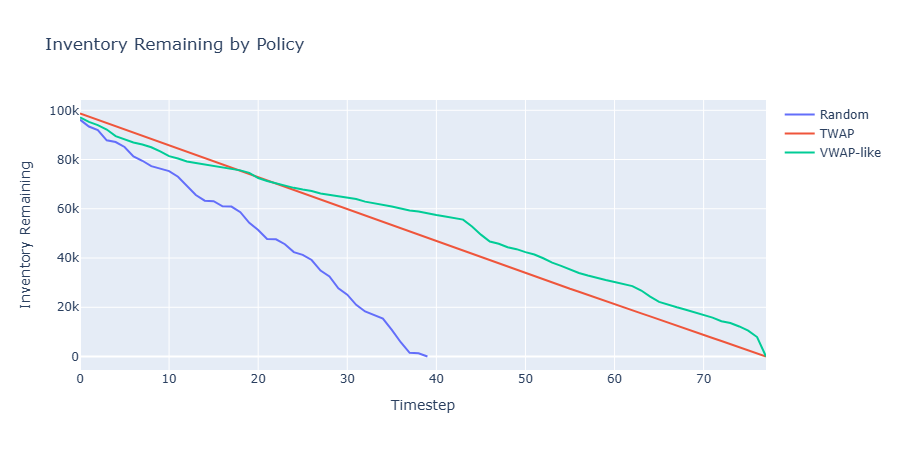

In [23]:
import plotly.graph_objects as go

histories = [
    history_random,
    history_twap,
    history_vwap
]

fig = go.Figure()

for history in histories:
    fig.add_trace(
        go.Scatter(
            x=history["t"],
            y=history["inventory_remaining"],
            mode="lines",
            name=history["policy"].iloc[0]
        )
    )

fig.update_layout(
    title="Inventory Remaining by Policy",
    xaxis_title="Timestep",
    yaxis_title="Inventory Remaining",
    height=450,
    width=900
)

fig.show()
fig.write_image("../results/plots/Inventory_Remaining_by_Policy.png")
display(Image(filename="../results/plots/Inventory_Remaining_by_Policy.png"))

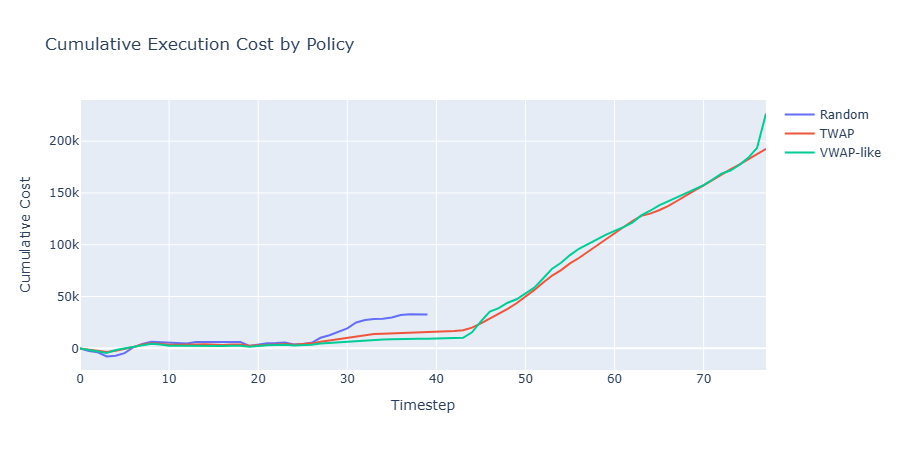

In [24]:
fig = go.Figure()

for history in histories:
    fig.add_trace(
        go.Scatter(
            x=history["t"],
            y=history["cumulative_cost"],
            mode="lines",
            name=history["policy"].iloc[0]
        )
    )

fig.update_layout(
    title="Cumulative Execution Cost by Policy",
    xaxis_title="Timestep",
    yaxis_title="Cumulative Cost",
    height=450,
    width=900
)

fig.show()
fig.write_image("../results/plots/Cumulative_Execution_Cost_by_Policy.png")
display(Image(filename="../results/plots/Cumulative_Execution_Cost_by_Policy.png"))

# <b> Validate Microstructure </b>

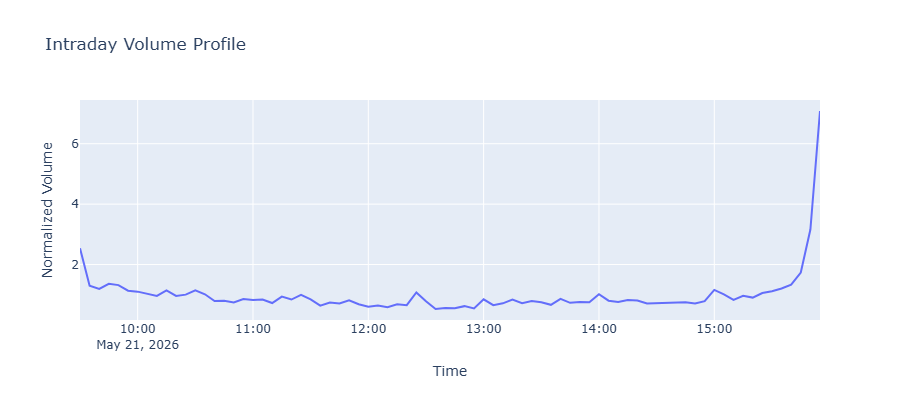

In [ ]:
fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=df_day.index,
        y=df_day["volume_profile_norm"],
        mode="lines",
        name="Normalized Volume Profile"
    )
)

fig.update_layout(
    title="Intraday Volume Profile",
    xaxis_title="Time",
    yaxis_title="Normalized Volume",
    height=400,
    width=900
)

fig.show()
fig.write_image("../results/plots/Intraday_Volume_Profile.png")
display(Image(filename="../results/plots/Intraday_Volume_Profile.png"))

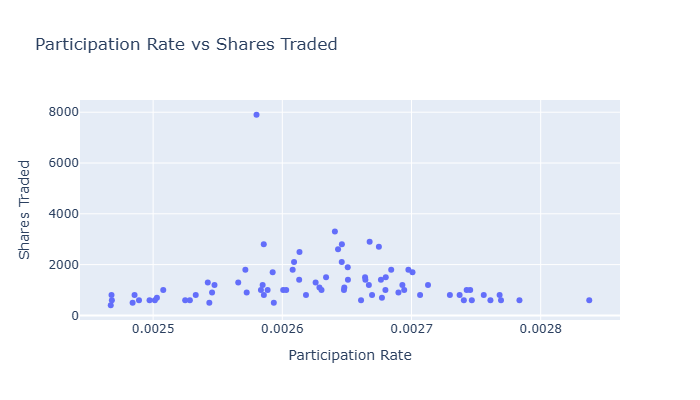

In [25]:
fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=history_vwap["participation_rate"],
        y=history_vwap["shares_traded"],
        mode="markers",
        name="VWAP Participation"
    )
)

fig.update_layout(
    title="Participation Rate vs Shares Traded",
    xaxis_title="Participation Rate",
    yaxis_title="Shares Traded",
    height=400,
    width=700
)

fig.show()
fig.write_image("../results/plots/Participation_Rate_vs_Shares_Traded.png")
display(Image(filename="../results/plots/Participation_Rate_vs_Shares_Traded.png"))